In [1]:
import os
import mudata as mu
import pertpy as pt
import scanpy as sc
import pandas as pd
import mudata as mu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

milo = pt.tl.Milo()

from pertpy.tools import Milo


In [2]:
adata_age_cd4= sc.read_h5ad("/scratch/user/s4575250/BIOX7014_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi.h5ad")

In [3]:
adata_age_cd4

AnnData object with n_obs × n_vars = 596486 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in 

In [4]:
adata_age_cd4.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata_age_cd4.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD4 naive/Tcm    407516
CD4 Tem           96510
Tfh               45002
Treg              39431
CD4 cytoT          8027
Name: count, dtype: int64

In [5]:
adata_age_cd4.obs["pica_id"].unique()
adata_age_cd4.obs["pica_id"].value_counts()

pica_id
PICA0008    8046
PICA0010    7871
PICA0024    7829
PICA0119    7760
PICA0089    7608
            ... 
PICA0006    1576
PICA0004    1203
PICA0003    1169
PICA0002    1009
PICA0005     685
Name: count, Length: 128, dtype: int64

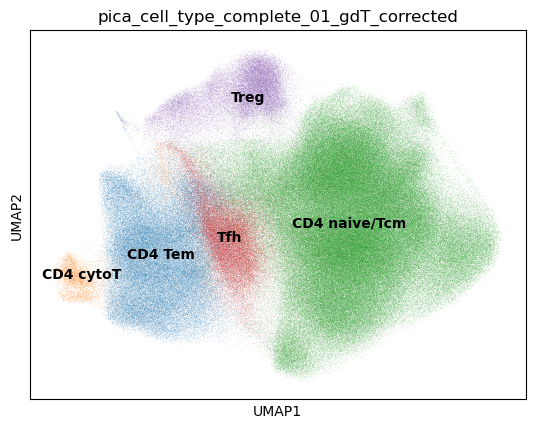

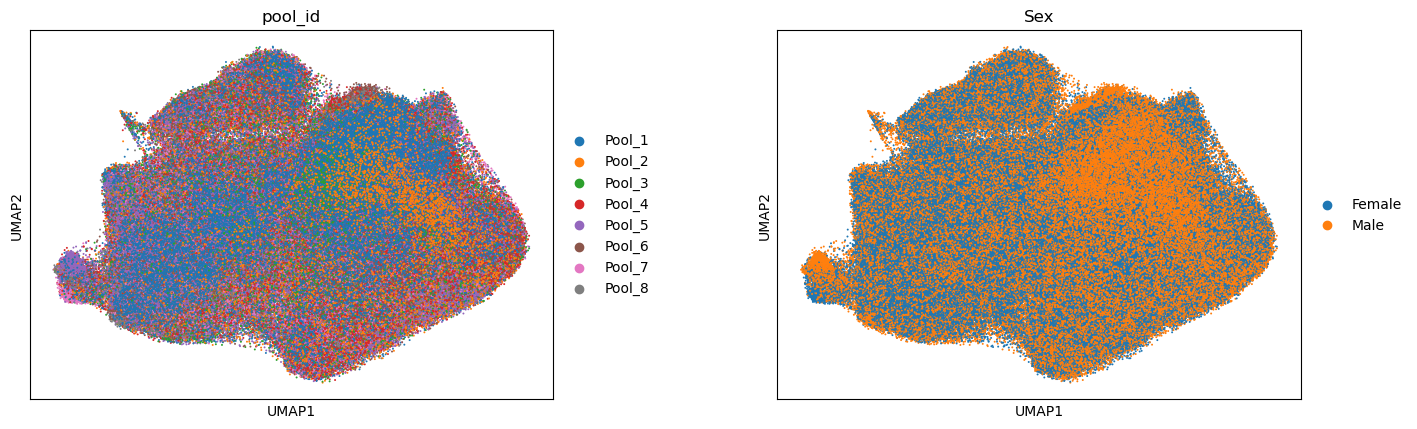

In [6]:
sc.pl.umap(adata_age_cd4, color=["pica_cell_type_complete_01_gdT_corrected"], legend_loc="on data")
sc.pl.umap(adata_age_cd4, color=["pool_id", "Sex"], wspace=0.3, size=8)

### Prepare for Milo analysis

In [7]:
adata_age_cd4.obs["Batch"] = adata_age_cd4.obs["Batch"].astype("category")
adata_age_cd4.obs["Age_years"] = adata_age_cd4.obs["Age_years"].astype("float")
adata_age_cd4.obs["Sex"] = adata_age_cd4.obs["Sex"].astype("category")
adata_age_cd4.obs["Age"] = adata_age_cd4.obs["Age"].astype("int")

In [8]:
adata_age_cd4.obs["Sex"].value_counts()


Sex
Male      321837
Female    274649
Name: count, dtype: int64

In [9]:
adata_age_cd4.obs["Age_years"].value_counts().sort_index()


Age_years
0.05     6493
0.07     7871
0.14     1576
0.35     6804
0.48     6077
         ... 
16.16    5594
16.20    5700
16.29    3669
16.78    4525
17.03    7608
Name: count, Length: 122, dtype: int64

In [10]:
adata_age_cd4.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      151860
4–6      134748
7–10      91711
11–14    162356
15–18     55811
Name: count, dtype: int64

In [11]:
adata_age_cd4.obs["Age"].value_counts().sort_index()

Age
0     52475
1     20322
2     39325
3     39738
4     59464
5     27998
6     47286
7     34567
8     25099
9     18081
10    13964
11    47405
12    28930
13    37178
14    48843
15    23877
16    24326
17     7608
Name: count, dtype: int64

In [12]:
adata_age_cd4.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")

/scratch/temp/22542103/ipykernel_652123/2554251018.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_age_cd4.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")


,Age_years,Sex,n_donors
0,0.05,Female,0
1,0.05,Male,1
2,0.07,Female,1
3,0.07,Male,0
4,0.14,Female,0
...,...,...,...
239,16.29,Male,1
240,16.78,Female,0
241,16.78,Male,1
242,17.03,Female,1


In [13]:
adata_age_cd4.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")

/scratch/temp/22542103/ipykernel_652123/1080512207.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_age_cd4.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")


,Age,Sex,n_donors
0,0,Female,3
1,0,Male,7
2,1,Female,1
3,1,Male,4
4,2,Female,1
5,2,Male,7
6,3,Female,6
7,3,Male,2
8,4,Female,6
9,4,Male,6


In [14]:
milo = pt.tl.Milo()
mdata_cd4 = milo.load(adata_age_cd4)

In [15]:
mdata_cd4

MuData object with n_obs × n_vars = 596486 × 38606
  2 modalities
    rna:	596486 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'Sex_colors'
      obsm:	'X_scVI', 'X_umap'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	0 x 0

In [16]:
# Build KNN graph
sc.pp.neighbors(mdata_cd4["rna"], use_rep="X_scVI", n_neighbors=150)

In [17]:
# Build neighbourhood graph
milo.make_nhoods(mdata_cd4["rna"], prop=0.1)

In [18]:
mdata_cd4["rna"].obsm["nhoods"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 15790561 stored elements and shape (596486, 32149)>

In [19]:
mdata_cd4["rna"][mdata_cd4["rna"].obs["nhood_ixs_refined"] != 0].obs[["nhood_ixs_refined", "nhood_kth_distance"]]

,nhood_ixs_refined,nhood_kth_distance
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCATTCGTAGTGC,1,3.950188
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAAGTGCAGCACGTCG,1,3.128820
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAAGTTACACAACATC,1,3.299845
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AACAGACAGAGCGACA,1,3.286461
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AACAGCCTCCACAGGT,1,3.817779
...,...,...
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTCATCGCAACGTACT,1,3.643885
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTGACTATCCAATTAA,1,3.361250
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTGTCGCCACCGGAAG,1,3.248476
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTCATGAGCAATTGT,1,3.210419


Text(0, 0.5, '# nhoods')

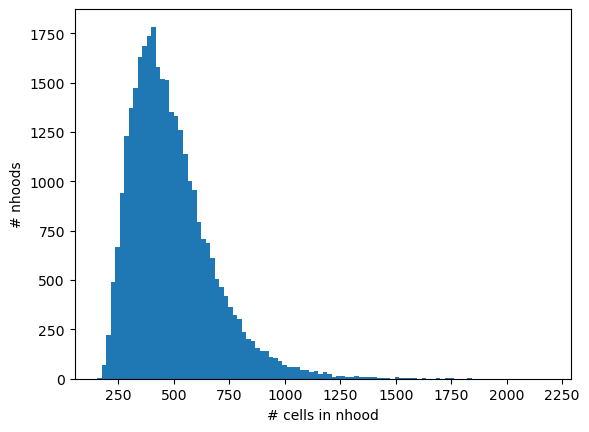

In [20]:
nhood_size = np.array(mdata_cd4["rna"].obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins=100)
plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods")

In [21]:
# count cells in neighbourhood
mdata_cd4= milo.count_nhoods(mdata_cd4, sample_col="pica_id") 

In [22]:
mdata_cd4

MuData object with n_obs × n_vars = 596486 × 38606
  2 modalities
    rna:	596486 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 32149
      var:	'index_cell', 'kth_distance'
      uns:	'sample_col'

In [23]:
mdata_cd4["milo"]

AnnData object with n_obs × n_vars = 128 × 32149
    var: 'index_cell', 'kth_distance'
    uns: 'sample_col'

In [24]:
donor_meta_cd4 = (
    adata_age_cd4.obs[["pica_id", "Age_years","Age", "Sex", "Batch","Age_group"]]
    .drop_duplicates("pica_id")
    .set_index("pica_id")
)
donor_meta_cd4 = donor_meta_cd4.loc[mdata_cd4["milo"].obs_names]

In [26]:
mdata_cd4["milo"].obs["Age_years"] = donor_meta_cd4["Age_years"].values
mdata_cd4["milo"].obs["Sex"] = donor_meta_cd4["Sex"].values
mdata_cd4["milo"].obs["Batch"] = donor_meta_cd4["Batch"].values
mdata_cd4["milo"].obs["Age"] = donor_meta_cd4["Age"].values
mdata_cd4["milo"].obs["Age_group"] = donor_meta_cd4["Age_group"].values


In [27]:

mdata_cd4["milo"].obs["Sex"] = mdata_cd4["milo"].obs["Sex"].astype("category")
mdata_cd4["milo"].obs["Age_years"] = mdata_cd4["milo"].obs["Age_years"].astype(float)
mdata_cd4["milo"].obs["Batch"] = mdata_cd4["milo"].obs["Batch"].astype("category")
mdata_cd4["milo"].obs["Age"] = mdata_cd4["milo"].obs["Age"].astype(int)
mdata_cd4["milo"].obs["Age_group"] = mdata_cd4["milo"].obs["Age_group"].astype("category")

In [ ]:
donor_meta_cd4

In [28]:
mdata_cd4["milo"]

AnnData object with n_obs × n_vars = 128 × 32149
    obs: 'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'
    var: 'index_cell', 'kth_distance'
    uns: 'sample_col'

In [29]:
mdata_cd4.write_h5mu(
    "/scratch/user/s4575250/BIOX7014_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_milo_nhoods_built.h5mu"
)

In [30]:
mdata_cd4["milo"].obs["Age_years"].value_counts().sort_index()

Age_years
0.05     1
0.07     1
0.14     1
0.35     1
0.48     1
        ..
16.16    1
16.20    1
16.29    1
16.78    1
17.03    1
Name: count, Length: 122, dtype: int64

In [31]:
mdata_cd4["milo"].obs["Sex"].value_counts().sort_index()

Sex
Female    53
Male      75
Name: count, dtype: int64

In [32]:
mdata_cd4["milo"].obs["Age_group"].value_counts().sort_index()

Age_group
0–3      31
4–6      29
7–10     21
11–14    34
15–18    13
Name: count, dtype: int64

In [33]:
mdata_cd4

MuData object with n_obs × n_vars = 596614 × 70755
  2 modalities
    rna:	596486 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 32149
      obs:	'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'
      var:	'ind